# 1. Постановка задачи
Данные представляют собой список, который содержит сведения о фильмах (1980-2020 годов): основная информация (названия, год и дата выхода), возрастной рейтинг, жанр, команда создателей (режиссер, сценарист и главный актер), пользовательский рейтинг IMDb по 10-балльной шкале и общее количество пользователей, поставивших оценку.

## Условный заказчик
Заказчиком анализа может выступать киностудия, производственная компания или стриминговый сервис, который хочет понять тенденции в киноиндустрии за данный период.
## Возможные задачи ИАД
- поиск ассоциативных правил;
- сегментация фильмов;
- описательная аналитика;


# 2. Паспорт датасета

In [3]:
%pip install pandas
%pip install matplotlib
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/movies.csv')
print(f"Количество строк: {df.shape[0]}\nКоличество столбцов: {df.shape[1]}\n")

columns_name = [col for col in df]
columns_descriptions = [
    'Название фильма',
    'Возрастной рейтинг (G, PG, R и др.)',
    'Жанр фильма',
    'Год производства фильма',
    'Дата релиза в формате "месяц, день, год"',
    'Оценка фильма на IMDb от 0 до 10',
    'Количество голосов (оценок)',
    'Режиссёр фильма',
    'Сценарист фильма',
    'Главный актёр/актриса',
    'Страна производства',
    'Бюджет фильма в долларах США',
    'Сборы фильма в долларах США',
    'Кинокомпания-производитель',
    'Продолжительность фильма в минутах'
]
columns_dtype_pd = [str(df[col].dtype) for col in df]

print('Список всех признаков, их текущих типов и описаний:')
for i in range(len(columns_name)):
    print(f"{columns_name[i]:<12} {columns_dtype_pd[i]:<10} - {columns_descriptions[i]}")

print("\nПреобразование типов данных...")
df['released'] = pd.to_datetime(
    df['released'].str.extract(r'([A-Za-z]+ \d{1,2}, \d{4})')[0],
    errors='coerce',
    format='%B %d, %Y'
)

df['rating'] = df['rating'].astype('category')
df['genre'] = df['genre'].astype('category')
df['country'] = df['country'].astype('category')
df['company'] = df['company'].astype('category')

numeric_columns = ['score', 'votes', 'budget', 'gross', 'runtime']
for col in numeric_columns:
    if col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].astype(str).str.replace(',', '')
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')

print(f'\nИтоговые преобразованные типы данных:\n{df.dtypes}')

Количество строк: 7997
Количество столбцов: 15

Список всех признаков, их текущих типов и описаний:
name         str        - Название фильма
rating       str        - Возрастной рейтинг (G, PG, R и др.)
genre        str        - Жанр фильма
year         int64      - Год производства фильма
released     str        - Дата релиза в формате "месяц, день, год"
score        float64    - Оценка фильма на IMDb от 0 до 10
votes        float64    - Количество голосов (оценок)
director     str        - Режиссёр фильма
writer       str        - Сценарист фильма
star         str        - Главный актёр/актриса
country      str        - Страна производства
budget       float64    - Бюджет фильма в долларах США
gross        float64    - Сборы фильма в долларах США
company      str        - Кинокомпания-производитель
runtime      float64    - Продолжительность фильма в минутах

Преобразование типов данных...

Итоговые преобразованные типы данных:
name                   str
rating            category
g

# 3. Аудит качества данных

3.1 Пропуски

          Количество пропусков  Доля пропусков, %
name                         0               0.00
rating                      82               1.03
genre                        0               0.00
year                         0               0.00
released                    61               0.76
score                        3               0.04
votes                        3               0.04
director                     2               0.03
writer                       3               0.04
star                         1               0.01
country                      5               0.06
budget                    2282              28.54
gross                      210               2.63
company                     17               0.21
runtime                      4               0.05

Вывод: бюджет отсутствует у 28.54% фильмов (2282 записи) - это делает невозможным точный финансовый анализ, пропуски кассовых сборов влияют на анализ коммерческой успешности, отсутствие

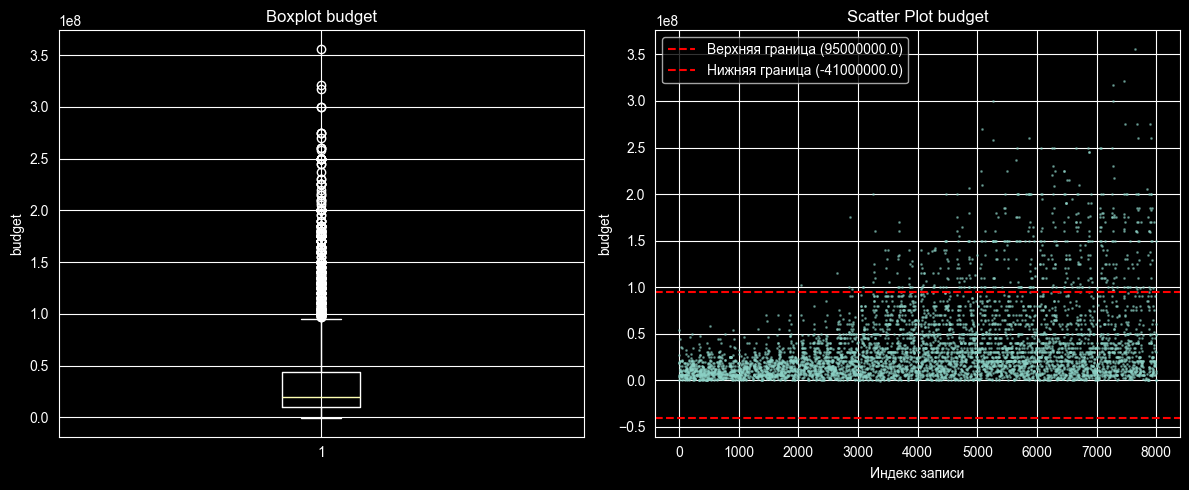


Анализ выбросов для score:
Метод IQR (границы: [3.9, 9.0]):
  Выбросов: 125 (1.56%)


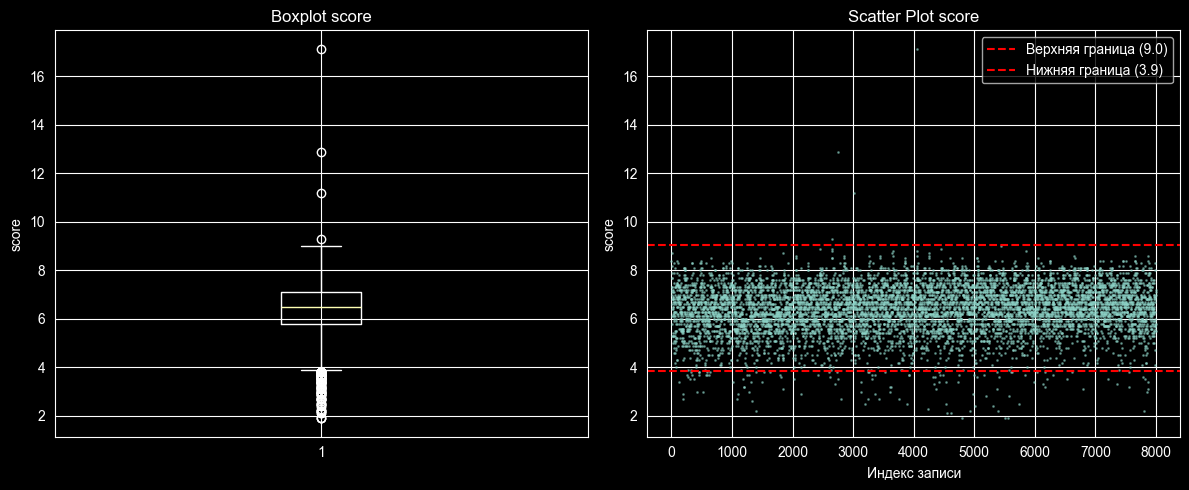

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

print("3.1 Пропуски\n")

missing_data = pd.DataFrame({
    'Количество пропусков': df.isnull().sum(),
    'Доля пропусков, %': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing_data)
print("\nВывод: бюджет отсутствует у 28.54% фильмов (2282 записи) - это делает невозможным точный финансовый анализ, пропуски кассовых сборов влияют на анализ коммерческой успешности, отсутствие рейтингов может искажать анализ возраста аудитории.")

print("\n3.2 Дубликаты")
print(f"Полностью дублирующихся строк: {df.duplicated().sum()}")

print("\n3.3 Типические проблемы значений\n")
print("Числовые признаки:")
numeric_cols = ['year', 'score', 'votes', 'budget', 'gross', 'runtime']
for col in numeric_cols:
    print(f"{col}:")
    print(f"  Min: {df[col].min():.2f}, Max: {df[col].max():.2f}")
    print(f"  Mean: {df[col].mean():.2f}, Std: {df[col].std():.2f}")
    print(f"  Медиана: {df[col].median():.2f}")

    if col == 'year':
            future_years = (df[col] > 2020).sum()
            very_old = (df[col] < 1980).sum()
            print(f"  Будущие года (>2020): {future_years}")
            print(f"  Слишком старые фильмы (<1980): {very_old}")

    if col == 'score':
        negative_scores = (df[col] < 0).sum()
        high_scores = (df[col] > 10).sum()
        print(f"  Отрицательные оценки: {negative_scores}")
        print(f"  Оценки >10: {high_scores}")

    if col == 'votes':
        negative_votes = (df[col] < 0).sum()
        print(f"  Отрицательные голоса: {negative_votes}")

    if col == 'budget':
        negative_budget = (df[col] < 0).sum()
        zero_budget = (df[col] == 0).sum()
        print(f"  Отрицательный бюджет: {negative_budget}")
        print(f"  Нулевой бюджет: {zero_budget}")

    if col == 'gross':
        negative_gross = (df[col] < 0).sum()
        zero_gross = (df[col] == 0).sum()
        print(f"  Отрицательные сборы: {negative_gross}")
        print(f"  Нулевые сборы: {zero_gross}")

    if col == 'runtime':
        negative_runtime = (df[col] < 0).sum()
        zero_runtime = (df[col] == 0).sum()
        very_short = ((df[col] > 0) & (df[col] < 10)).sum()
        very_long = (df[col] > 300).sum()
        print(f"  Отрицательная длительность: {negative_runtime}")
        print(f"  Нулевая длительность: {zero_runtime}")
        print(f"  Очень короткие фильмы (<10 мин): {very_short}")
        print(f"  Очень длинные фильмы (>300 мин): {very_long}")
        print()
        print(df.loc[df['runtime'] > 300, ['name', 'runtime']])
    print()

print("\nКатегориальные признаки:")
cat_cols = df.select_dtypes(include=['category']).columns
for col in cat_cols:
    unique_count = df[col].nunique()
    print(f"{col}: {unique_count} уникальных значений")

    if col in df.columns:
        leading_spaces = df[col].str.startswith(' ').sum()
        trailing_spaces = df[col].str.endswith(' ').sum()
        multiple_spaces = df[col].str.contains('  ').sum()

        if leading_spaces > 0 or trailing_spaces > 0 or multiple_spaces > 0:
            print(f"  Пробелы: начальные={leading_spaces}, конечные={trailing_spaces}, множественные={multiple_spaces}")


        unique_vals = df[col].dropna().unique()
        mixed_case = 0
        for val in unique_vals:
            if not (val.islower() or val.isupper() or val.istitle()):
                mixed_case += 1

        if mixed_case > 0:
            print(f"  Смешанный регистр: {mixed_case} значений")


print("\n3.4 Выбросы")
outliers_cols = ['budget', 'score']
for col in outliers_cols:
    print(f"\nАнализ выбросов для {col}:")

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_iqr = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Метод IQR (границы: [{lower_bound:.1f}, {upper_bound:.1f}]):")
    print(f"  Выбросов: {len(outliers_iqr)} ({len(outliers_iqr)/len(df)*100:.2f}%)")


    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].boxplot(df[col].dropna())
    axes[0].set_title(f'Boxplot {col}')
    axes[0].set_ylabel(col)

    axes[1].scatter(range(len(df)), df[col], alpha=0.5, s=1)
    axes[1].axhline(y=upper_bound, color='r', linestyle='--', label=f'Верхняя граница ({upper_bound:.1f})')
    axes[1].axhline(y=lower_bound, color='r', linestyle='--', label=f'Нижняя граница ({lower_bound:.1f})')
    axes[1].set_title(f'Scatter Plot {col}')
    axes[1].set_xlabel('Индекс записи')
    axes[1].set_ylabel(col)
    axes[1].legend()


    plt.tight_layout()
    plt.show()


# 4. Разведочный анализ


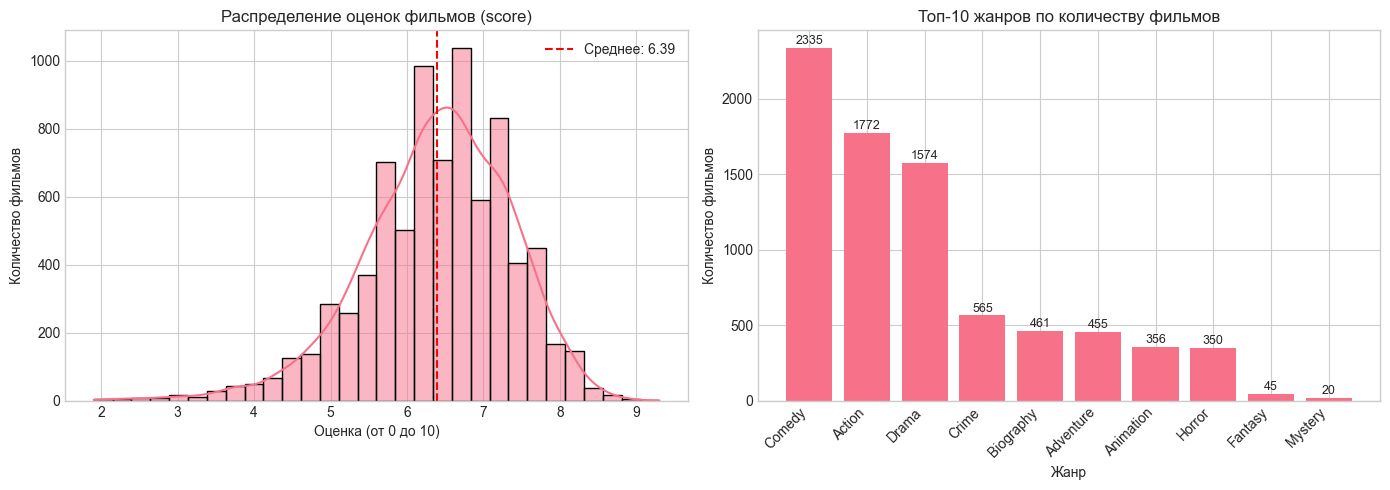

Комментарий к графику 1 (распределение оценок):
• Большинство фильмов имеют оценки от 5 до 8, что указывает на преобладание средних оценок
• Гипотеза: Фильмы с оценками выше 8 являются исключительными, а ниже 4 - низкокачественными
• Вопрос: Какие факторы влияют на получение экстремально высоких или низких оценок?

Комментарий к графику 2 (распределение жанров):
• Комедия и драма - самые популярные жанры в датасете
• Гипотеза: В исследуемый период эти жанры были наиболее востребованными у зрителей
• Вопрос: Как популярность жанров коррелирует с финансовыми показателями фильмов?



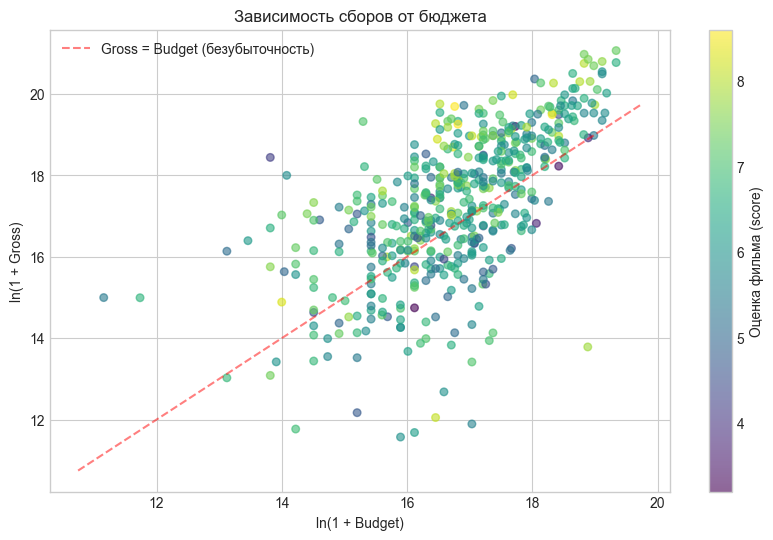

Комментарий к графику 3 (зависимость сборов от бюджета):
• Наблюдается положительная корреляция: фильмы с большим бюджетом обычно приносят больше сборов
• Гипотеза: Существует оптимальный диапазон бюджета для максимальной рентабельности
• Вопрос: Какие фильмы являются исключениями (низкий бюджет, но высокие сборы или наоборот)?


In [25]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# График 1: Распределение оценок фильмов - числовой признак
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
scores = df['score'].dropna()[df['score'].dropna() <= 10]
sns.histplot(scores, kde=True, bins=30, ax=ax1)
ax1.set_title('Распределение оценок фильмов (score)')
ax1.set_xlabel('Оценка (от 0 до 10)')
ax1.set_ylabel('Количество фильмов')
ax1.axvline(df['score'].mean(), color='red', linestyle='--',
           label=f'Среднее: {df["score"].mean():.2f}')
ax1.legend()

# График 2: Топ-10 жанров по количеству фильмов - категориальный признак
ax2 = axes[1]
top_genres = df['genre'].value_counts().head(10)
bars = ax2.bar(range(len(top_genres)), top_genres.values)
ax2.set_title('Топ-10 жанров по количеству фильмов')
ax2.set_xlabel('Жанр')
ax2.set_ylabel('Количество фильмов')
ax2.set_xticks(range(len(top_genres)))
ax2.set_xticklabels(top_genres.index, rotation=45, ha='right')

for bar, value in zip(bars, top_genres.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{value}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
print("Комментарий к графику 1 (распределение оценок):")
print("• Большинство фильмов имеют оценки от 5 до 8, что указывает на преобладание средних оценок")
print("• Гипотеза: Фильмы с оценками выше 8 являются исключительными, а ниже 4 - низкокачественными")
print("• Вопрос: Какие факторы влияют на получение экстремально высоких или низких оценок?\n")

print("Комментарий к графику 2 (распределение жанров):")
print("• Комедия и драма - самые популярные жанры в датасете")
print("• Гипотеза: В исследуемый период эти жанры были наиболее востребованными у зрителей")
print("• Вопрос: Как популярность жанров коррелирует с финансовыми показателями фильмов?\n")

# График 3: Зависимость сборов от бюджета
fig2, ax3 = plt.subplots(1, 1, figsize=(10, 6))

financial_df = df.dropna(subset=['budget', 'gross'])
sample_size = min(500, len(financial_df))
sample_df = financial_df.sample(sample_size, random_state=41)

scatter = ax3.scatter(np.log1p(sample_df['budget']), np.log1p(sample_df['gross']),
                     alpha=0.6, s=30, c=sample_df['score'], cmap='viridis')
ax3.set_title('Зависимость сборов от бюджета')
ax3.set_xlabel('ln(1 + Budget)')
ax3.set_ylabel('ln(1 + Gross)')

cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Оценка фильма (score)')

x_vals = np.array(ax3.get_xlim())
ax3.plot(x_vals, x_vals, 'r--', alpha=0.5, label='Gross = Budget (безубыточность)')
ax3.legend()

plt.show()

print("Комментарий к графику 3 (зависимость сборов от бюджета):")
print("• Наблюдается положительная корреляция: фильмы с большим бюджетом обычно приносят больше сборов")
print("• Гипотеза: Существует оптимальный диапазон бюджета для максимальной рентабельности")
print("• Вопрос: Какие фильмы являются исключениями (низкий бюджет, но высокие сборы или наоборот)?")